# 🏎️ Tyre Degradation Analysis — Bahrain GP 2024

## What this notebook does
Explores how F1 tyre performance degrades over a race stint using real telemetry
data from FastF1. The goal is to understand and eventually predict lap time
degradation based on tyre compound and age.

## Concepts used
- **FastF1**: Python library to access official F1 timing and telemetry data
- **Session**: A race/qualifying event loaded from FastF1
- **Laps DataFrame**: One row per lap per driver, contains timing and tyre info
- **Stint**: Period between two pit stops — tyre life resets each stint
- **Compound**: Tyre type — SOFT (fast, wears quickly), MEDIUM, HARD (slow, lasts longer)
- **TrackStatus == '1'**: Green flag laps only — no safety car or red flag distortion

## What I learned
- FastF1 downloads data on first run and caches it locally for speed
- Raw lap data contains noise (pit laps, safety car laps) that must be cleaned before analysis
- Tyre degradation is visible even in a scatter plot — lap times slowly increase with tyre age
- Hard tyres last ~30 laps, Softs only ~5 in Bahrain conditions

## Next steps
- Build a regression model to predict lap time from tyre life and compound
- Compare degradation rates between compounds quantitatively
- Add fuel correction (cars get lighter = faster as fuel burns off)

In [ ]:
!pip install fastf1 pandas numpy matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import fastf1

# Create the cache folder if it doesn't exist
os.makedirs('/content/drive/MyDrive/f1_cache', exist_ok=True)

fastf1.Cache.enable_cache('/content/drive/MyDrive/f1_cache')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

session = fastf1.get_session(2024, 'Bahrain', 'R')
session.load()

laps = session.laps
print(laps.columns.tolist())

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core         

['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


In [ ]:
# Keep only the columns we care about and clean the data
tyre_data = laps[['Driver', 'Team', 'LapNumber', 'LapTime',
                   'Compound', 'TyreLife', 'Stint', 'TrackStatus']].copy()

# Convert LapTime to seconds (it's a timedelta)
tyre_data['LapTimeSeconds'] = tyre_data['LapTime'].dt.total_seconds()

# Drop laps with missing values
tyre_data = tyre_data.dropna(subset=['LapTimeSeconds', 'Compound', 'TyreLife'])

print(tyre_data.shape)
print(tyre_data.head(10))

(1127, 9)
  Driver             Team  LapNumber                LapTime Compound  \
0    VER  Red Bull Racing        1.0 0 days 00:01:37.284000     SOFT   
1    VER  Red Bull Racing        2.0 0 days 00:01:36.296000     SOFT   
2    VER  Red Bull Racing        3.0 0 days 00:01:36.753000     SOFT   
3    VER  Red Bull Racing        4.0 0 days 00:01:36.647000     SOFT   
4    VER  Red Bull Racing        5.0 0 days 00:01:37.173000     SOFT   
5    VER  Red Bull Racing        6.0 0 days 00:01:37.092000     SOFT   
6    VER  Red Bull Racing        7.0 0 days 00:01:37.038000     SOFT   
7    VER  Red Bull Racing        8.0 0 days 00:01:37.024000     SOFT   
8    VER  Red Bull Racing        9.0 0 days 00:01:37.229000     SOFT   
9    VER  Red Bull Racing       10.0 0 days 00:01:36.960000     SOFT   

   TyreLife  Stint TrackStatus  LapTimeSeconds  
0       4.0    1.0          12          97.284  
1       5.0    1.0           1          96.296  
2       6.0    1.0           1          96.753  
3

In [ ]:
#See ho many laps per compound
print(tyre_data['Compound'].value_counts())
print()

#See lap tim range
print(f"Fastest lap: {tyre_data['LapTimeSeconds'].min():.2f}s")
print(f"Slowest lap: {tyre_data['LapTimeSeconds'].max():.2f}s")
print()

#See tyre life range
print(f"Max tyre life: {tyre_data['TyreLife'].max()} laps")

Compound
HARD    790
SOFT    337
Name: count, dtype: int64

Fastest lap: 92.61s
Slowest lap: 132.44s

Max tyre life: 30.0 laps


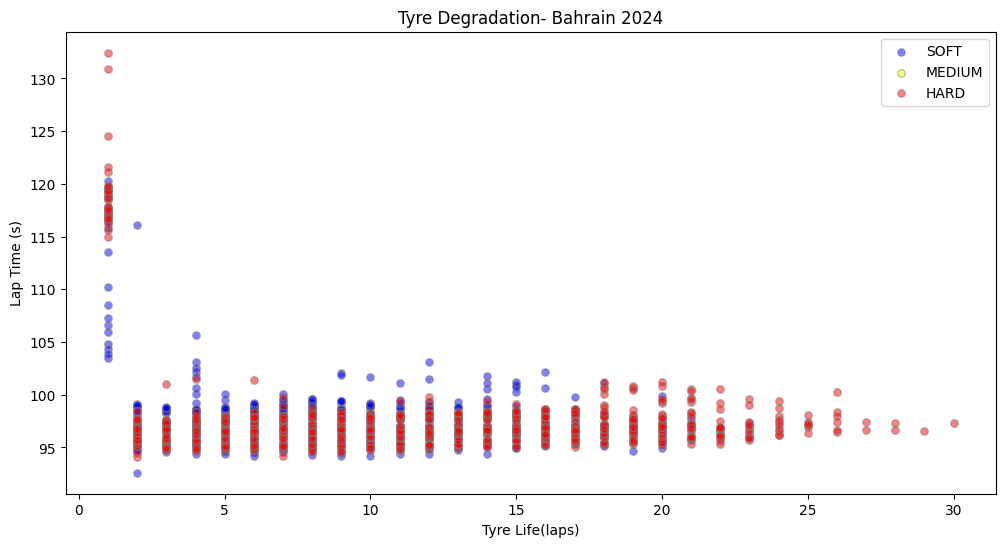

In [ ]:
fig,ax= plt.subplots(figsize=(12,6))

compounds= {'SOFT': 'red', 'MEDIUM':'yellow', 'HARD': 'blue'}

for compound, color in compounds.items():
  data=tyre_data[tyre_data['Compound']==compound]
  ax.scatter(data['TyreLife'],data['LapTimeSeconds'],
             c=color, label=compound, alpha=0.5,edgecolors='gray',s=30)

ax.set_xlabel('Tyre Life(laps)')
ax.set_ylabel('Lap Time (s)')
ax.set_title('Tyre Degradation- Bahrain 2024')
ax.legend()
plt.show()

## Visualizing Tyre Degradation

Each dot is a single lap by a single driver. X axis shows hoy many laps the tyre has been on, Y axis ahows lap time in seconds.

We expect to see lap times slowly increase as tyres age - rthis is degradation.
The spread of dots at each tyre age comes from the pace differnece between faster and slower cars on the grid.

Key observations:
- Hard tyres last up to 30 laps, Softs rarely exceed 15
- Even on old tyres, fast cars (bottom dots) beat slow cars (top dots)
- This tells us we need to account for car/driver pace in our model

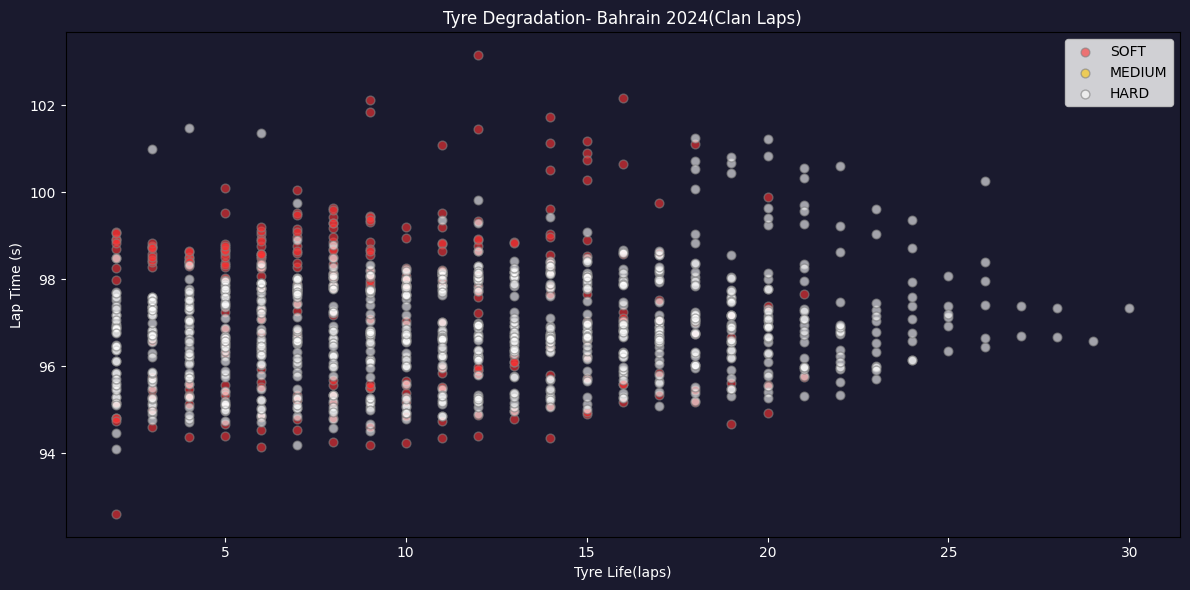

Laps before cleaning: 1127
Laps after cleaning: 1046


In [ ]:
clean_laps= tyre_data[(tyre_data['LapTimeSeconds']<105) & (tyre_data['TrackStatus']=='1') & (tyre_data['TyreLife']>1)].copy()

fig, ax=plt.subplots(figsize=(12,6))

compound_colors= {'SOFT': '#FF3333',
    'MEDIUM': '#FFC906',
    'HARD': '#FFFFFF'        }

for compound, color in compound_colors.items():
  data=clean_laps[clean_laps['Compound']==compound]
  ax.scatter(data['TyreLife'],data['LapTimeSeconds'],
             c=color, label=compound, alpha=0.6,edgecolors='gray',s=40)

ax.set_xlabel('Tyre Life(laps)',color='white')
ax.set_ylabel('Lap Time (s)',color='white')
ax.set_title('Tyre Degradation- Bahrain 2024(Clan Laps)',color='white')
ax.legend()
ax.tick_params(colors='white')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.show()

print(f"Laps before cleaning: {len(tyre_data)}")
print(f"Laps after cleaning: {len(clean_laps)}")

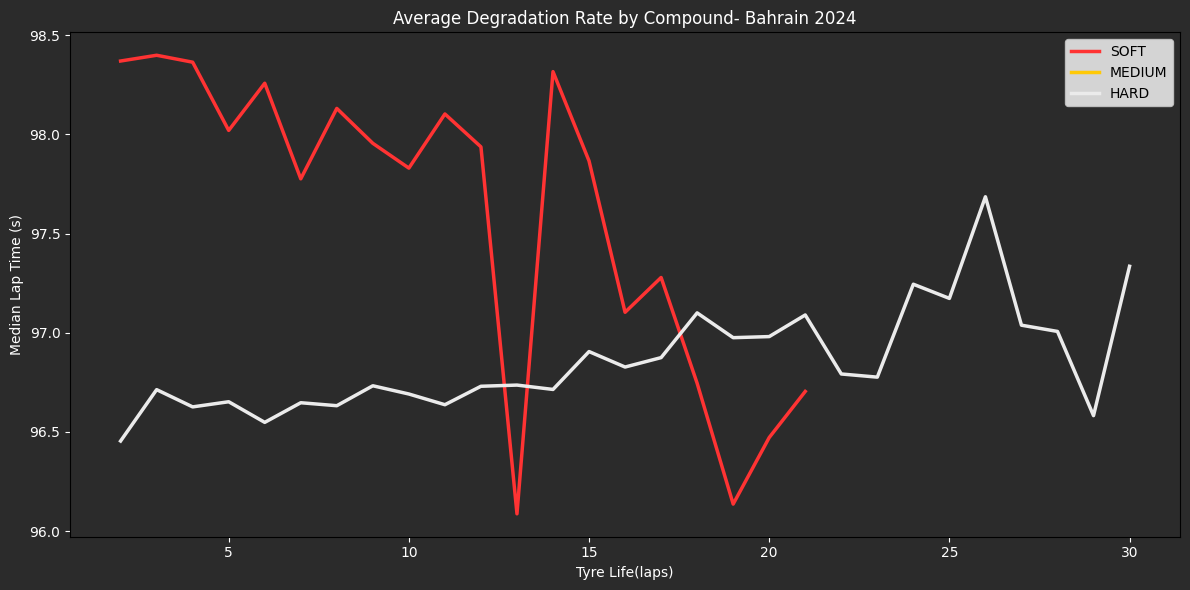

In [ ]:
#Average lap time per compund per tyre age
degradation= clean_laps.groupby(['Compound','TyreLife'])['LapTimeSeconds'].median().reset_index()

fig, ax= plt.subplots(figsize=(12,6))

compound_colors = {'SOFT': '#FF3333', 'MEDIUM': '#FFC906', 'HARD': '#EBEBEB'}

for compound, color in compound_colors.items():
  data=degradation[degradation['Compound']==compound]
  ax.plot(data['TyreLife'],data['LapTimeSeconds'],
          color=color, label=compound, linewidth=2.5)

ax.set_xlabel('Tyre Life(laps)',color='white')
ax.set_ylabel('Median Lap Time (s)',color='white')
ax.set_title('Average Degradation Rate by Compound- Bahrain 2024',color='white')
ax.legend()
ax.tick_params(colors='white')
ax.set_facecolor('#2b2b2b')
fig.patch.set_facecolor('#2b2b2b')
plt.tight_layout()
plt.show()

## Average Degradation Rate by Compound

This chart shows the median lap time for each tyre compound as it ages.
Instead of showing every individual lap (like the scatter plot), we take
the median at each tyre age to see the general trend clearly.

Key findings:
- Hard tyres start slower (~96.5s) but are very consistent up to 30 laps
- Soft tyres start faster but show more variance and nobody runs them past lap 20
- Medium tyres are barely used in Bahrain 2024 — it was essentially a Soft/Hard race
- The spikes in the Soft line at laps 13-14 are noise (very few drivers on that compound that late)

Conclusion: compound alone doesn't fully explain lap time — we need more features.

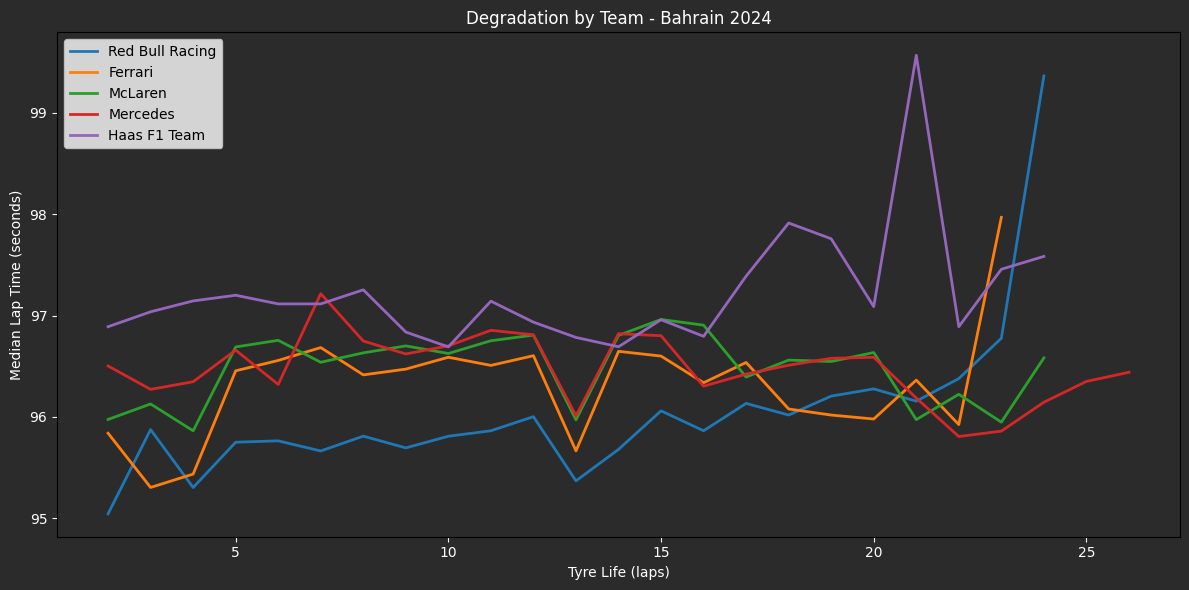

In [ ]:
#Top 5 teams only to keeep it readable
top_teams= clean_laps.groupby('Team')['LapTimeSeconds'].median().nsmallest(5).index

fig, ax= plt.subplots(figsize=(12,6))

for team in top_teams:
  data=clean_laps[clean_laps['Team']==team].groupby('TyreLife')['LapTimeSeconds'].median()
  ax.plot(data.index,data.values,label=team, linewidth=2)

ax.set_xlabel('Tyre Life (laps)', color='white')
ax.set_ylabel('Median Lap Time (seconds)', color='white')
ax.set_title('Degradation by Team - Bahrain 2024', color='white')
ax.legend()
ax.tick_params(colors='white')
ax.set_facecolor('#2b2b2b')
fig.patch.set_facecolor('#2b2b2b')
plt.tight_layout()
plt.show()

## Degradation by Team

Same analysis but split by team instead of compound. This tells us whether
car/team differences matter enough to include in our model.

Key findings:
- Red Bull (blue) is consistently the fastest — best car + best tyre management
- Haas (purple) shows big spikes — they struggled with tyre management all 2024 season
- Top teams (Red Bull, Ferrari, McLaren, Mercedes) stay within ~1 second of each other
- The gap between best and worst is ~2 seconds at the same tyre age

Conclusion: Team is an important feature for our model. Two cars on the same
tyre at the same age can have very different lap times depending on the car.

## EDA Summary — What we learned

After exploring Bahrain 2024 race data we now know:

1. Data needs cleaning — pit laps, safety car laps and outliers must be removed
2. Tyre degradation is real but noisy — ML is better than a simple formula
3. Compound matters — different baseline pace and wear rate
4. Team matters — car pace affects lap time independently of tyres
5. Degradation is not perfectly linear — it varies lap to lap

Features we will use in our model:
- TyreLife (how old the tyre is)
- Compound (SOFT / MEDIUM / HARD)
- Team (car pace baseline)
- LapNumber (fuel load decreases as race goes on = car gets lighter = faster)
- TrackTemp (hotter track = faster tyre degradation)
- AirTemp (affects engine and tyre performance)
- Rainfall (wet conditions completely change lap times)

Target variable we want to predict:
- LapTimeSeconds

Next step: load multiple races and build the regression model.